# SEIRS-SEI Malaria Model — M' Calibration with Warm-Up

Calibrating `M_prime` (mosquito carrying capacity base) to match observed I_H over 2017–2023,
using a **warm-up / spin-up** (2012–2016) to generate initial conditions.

The warm-up uses **calibrated 2012 ICs** from `SEIRS_SEI_ODE_IC_Calibration.ipynb`
(E_H0=1% N, R_H0=5% N, I_M0=0.2% M_0) and runs for 5 years before the data period.
The system converges to its natural limit cycle, and the final state becomes the 2017 initial condition.

**This eliminates the dependence on arbitrary ICs and allows the M' fit to be driven purely by the data.**

Based on `ode_models/SEIRS_SEI_ODE_Mprime_Calibration.ipynb`.


In [2]:
import sys
sys.path.append("..")

from ode_models.seirs_sei_ode_shared import *
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")


Data loaded and filtered successfully!
Climate data: 2556 days
Cases data: 2556 days
Deforestation data: 3288 days
Forest fires data: 3288 days

IBGE rural population by year (2017-2023):
2017: 8368.62
2018: 8260.48
2019: 8152.73
2020: 8045.43
2021: 7938.61
2022: 7832.33
2023: 7942.25
The initial ratio of exposed to infected mosquitos in 2012 was estimated to be ~4
The initial ratio of exposed to infected mosquitos was estimated to be ~3
Initial human compartments in 2017: N=8369, S_H=5752, E_H=418, I_H=944, R_H=1255
Initial mosquito compartments in 2017: M=83690, S_M=80342, E_M=2511, I_M=837


## Load Extended Climate Data (2012–2024)

Load both 2012–2015 and 2016–2024 climate CSVs and concatenate for a continuous 2012–2023 dataset.


In [4]:
#### Load and concatenate climate data 2012-2024
climate_2012_2015 = pd.read_csv(
    os.path.join(DATA_DIR, "climate_api_data_2012_2015.csv")
)
climate_2016_2024 = pd.read_csv(
    os.path.join(DATA_DIR, "climate_api_data_2016_2024.csv")
)

climate_2012_2015["date"] = pd.to_datetime(climate_2012_2015["date"])
climate_2016_2024["date"] = pd.to_datetime(climate_2016_2024["date"])

climate_full = pd.concat([climate_2012_2015, climate_2016_2024], ignore_index=True)
climate_full = climate_full[
    (climate_full['date'] >= '2012-01-01') & (climate_full['date'] <= '2023-12-31')
].reset_index(drop=True)

warmup_end_idx = (climate_full['date'] < '2017-01-01').sum()
num_total_days = len(climate_full)

print(f"Climate data 2012-2023: {num_total_days} days")
print(f"Warm-up (2012-2016): {warmup_end_idx} days")
print(f"Main period (2017-2023): {num_total_days - warmup_end_idx} days")

# Add smoothed columns
climate_full["temp_med_smooth"] = (
    climate_full["temp_med"]
    .rolling(SMOOTH_WINDOW, min_periods=1, center=False)
    .mean()
)
climate_full["precip_med_smooth"] = (
    climate_full["precip_med"]
    .rolling(SMOOTH_WINDOW, min_periods=1, center=False)
    .mean()
)
climate_full["umid_min_smooth"] = (
    climate_full["umid_min"]
    .rolling(SMOOTH_WINDOW, min_periods=1, center=False)
    .mean()
)


Climate data 2012-2023: 4383 days
Warm-up (2012-2016): 1827 days
Main period (2017-2023): 2556 days


## Calibrated Initial Conditions (2012-01-01)

Using the optimized ICs from `SEIRS_SEI_ODE_IC_Calibration.ipynb`:
- E_H0 = 1% N, R_H0 = 5% N, I_M0 = 0.2% M_0
- I_H0 is fixed at `warmup_I_H0` (from the 2012 notification data)

These calibrated ICs replace the generic defaults previously used.


In [6]:
#### Fitted conditions
H0 = 65.0
k = 0.75
phi = 0.03

tau_H = 21
gamma = 1/180
omega = 1/730

b1 = 0.15
b2 = 0.03

N_warmup = round(pop_by_year[2012])
M_0_warmup = 10 * N_warmup

# Optimized ICs from IC Calibration
I_H_warmup = warmup_I_H0                     # 1766 (from notification data)
S_H_warmup = round(N_warmup * 0.25)  
E_H_warmup = round(N_warmup * 0.05)          #round(N_warmup * 0.01)           # 1% (optimized)
# R_H_warmup = round(N_warmup * 0.05)        # 5% (optimized)
R_H_warmup = N_warmup - S_H_warmup - E_H_warmup - I_H_warmup # - R_H_warmup

I_M_warmup = round(M_0_warmup * 0.001)        # 0.2% (optimized)
E_M_warmup = round(I_M_warmup * 2.5)          # match IC calibration warmup
S_M_warmup = M_0_warmup - E_M_warmup - I_M_warmup

state_warmup_init = np.array([S_H_warmup, E_H_warmup, I_H_warmup, R_H_warmup,
                               S_M_warmup, E_M_warmup, I_M_warmup])

# Use a default M_prime for the warm-up (close to expected optimal)
M_prime_warmup = 40 * N_warmup

print(f"Calibrated 2012 ICs: N={N_warmup}, S_H={S_H_warmup}, E_H={E_H_warmup}, I_H={I_H_warmup}, R_H={R_H_warmup}")
print(f"  Mosquito: S_M={S_M_warmup}, E_M={E_M_warmup}, I_M={I_M_warmup}")


Calibrated 2012 ICs: N=8914, S_H=2228, E_H=446, I_H=1766, R_H=4474
  Mosquito: S_M=88829, E_M=222, I_M=89


## Warm-Up Simulation (2012–2016)

Run the model with calibrated initial conditions for 5 years prior to the data period.
The final state becomes the initial condition for 2017.


In [8]:
def ode_warmup(t, z):
    return seirs_sei_ode(
        t, z, N_warmup, climate_full,
        T_prime, B_E, p_ME, p_ML, p_MP, tau_E, tau_P,
        c1, c2, D1, b1, b2, A, B, C, DD,
        Tmin, optimal_temp_plasm, critical_max_temp_plasm,
        optimal_temp_anop, critical_max_temp_anop, critical_min_temp_anop,
        gamma, R_L, M_prime_warmup, tau_H, omega,
        M_min=M_min, permanent_factor=permanent_factor,
        use_smooth_climate=USE_SMOOTH_CLIMATE,
    )

print("Running warm-up (2012-01-01 to 2016-12-31)...")
sol_warmup = solve_ivp(
    ode_warmup,
    (0, warmup_end_idx),
    state_warmup_init,
    t_eval=np.arange(0, warmup_end_idx, 1),
    method='LSODA'
)

if not sol_warmup.success:
    raise RuntimeError("Warm-up failed!")

warmup_end_state = sol_warmup.y[:, -1].copy()
warmup_end_state = np.maximum(warmup_end_state, 0)

print(f"Warm-up complete. End state for 2017:")
print(f"  S_H={warmup_end_state[0]:.0f}, E_H={warmup_end_state[1]:.0f}, I_H={warmup_end_state[2]:.0f}, R_H={warmup_end_state[3]:.0f}")
print(f"  S_M={warmup_end_state[4]:.0f}, E_M={warmup_end_state[5]:.0f}, I_M={warmup_end_state[6]:.0f}")


Running warm-up (2012-01-01 to 2016-12-31)...
Warm-up complete. End state for 2017:
  S_H=6165, E_H=37, I_H=340, R_H=2373
  S_M=226175, E_M=3306, I_M=623


## Yearly Simulation (2017–2023) with Calibrated Warm-Up ICs

Run the model year by year with a given M_prime, using the warm-up end state as initial condition (from calibrated 2012 ICs).


In [10]:
years = list(range(2017, 2024))

def run_simulation_with_M(M_prime_val, initial_state=None):
    if initial_state is None:
        init_state = warmup_end_state.copy()
    else:
        init_state = initial_state.copy()
    all_IH = []
    all_dates = []
    current_state = init_state
    for year in years:
        N = round(pop_by_year[year])
        start = f"{year}-01-01"
        end = f"{year}-12-31"
        year_climate = climate_data[
            (climate_data['date'] >= start) & (climate_data['date'] <= end)
        ].reset_index(drop=True)
        if USE_SMOOTH_CLIMATE:
            year_climate['temp_med_smooth'] = year_climate['temp_med'].rolling(SMOOTH_WINDOW, min_periods=1, center=False).mean()
            year_climate['precip_med_smooth'] = year_climate['precip_med'].rolling(SMOOTH_WINDOW, min_periods=1, center=False).mean()
            year_climate['umid_min_smooth'] = year_climate['umid_min'].rolling(SMOOTH_WINDOW, min_periods=1, center=False).mean()
        num_days = len(year_climate)
        def ode_func(t, z):
            return seirs_sei_ode(
                t, z, N, year_climate,
                T_prime, B_E, p_ME, p_ML, p_MP, tau_E, tau_P,
                c1, c2, D1, b1, b2, A, B, C, DD,
                Tmin, optimal_temp_plasm, critical_max_temp_plasm,
                optimal_temp_anop, critical_max_temp_anop, critical_min_temp_anop,
                gamma, R_L, M_prime_val, tau_H, omega,
                M_min=M_min, permanent_factor=permanent_factor,
                use_smooth_climate=USE_SMOOTH_CLIMATE
            )
        sol = solve_ivp(
            ode_func, [0, num_days], current_state,
            t_eval=np.linspace(0, num_days, num_days * 10), method='LSODA'
        )
        if not sol.success:
            return np.array([]), np.array([])
        current_state = sol.y[:, -1].copy()
        current_state = np.maximum(current_state, 0)
        t_interp = np.linspace(0, sol.t[-1], len(year_climate))
        IH_interp = interp1d(sol.t, sol.y[2])(t_interp)
        all_IH.extend(IH_interp)
        all_dates.extend(year_climate['date'].values)
    return np.array(all_dates), np.array(all_IH)


## Objective Function

MSE between model I_H and observed active_total over 2017–2023.

**Key change**: The warm-up is now re-run inside the objective function
using the **same M_prime_val being tested**, so the warm-up and calibration
use a consistent carrying capacity. This prevents the warm-up from generating
2017 ICs that are incompatible with the calibrated M'.

The K_0 ≥ M_0 constraint from the original M' calibration is also applied.


In [12]:
#### Objective function with warm-up using same M_prime_val

def objective_function(log_M_prime):
    M_prime_val = np.exp(log_M_prime)
    
    T0_smooth = climate_data['temp_med_smooth'].iloc[0]
    R0_smooth = climate_data['precip_med_smooth'].iloc[0]
    f_T_0 = temp_factor_briere_normalized_anop(T0_smooth)
    habitat_creating_factor_0 = 2 * R0_smooth / R_L
    habitat_flushing_factor_0 = np.exp(1 - (2 * R0_smooth / R_L))
    f_R_0 = habitat_creating_factor_0 * habitat_flushing_factor_0
    K_0 = M_prime_val * f_T_0 * f_R_0
    if M_0 > K_0:
        return 1e15
    
    #### Warm-up with the SAME M_prime_val (not the fixed M_prime_warmup)
    def ode_warmup_local(t, z):
        return seirs_sei_ode(
            t, z, N_warmup, climate_full,
            T_prime, B_E, p_ME, p_ML, p_MP, tau_E, tau_P,
            c1, c2, D1, b1, b2, A, B, C, DD,
            Tmin, optimal_temp_plasm, critical_max_temp_plasm,
            optimal_temp_anop, critical_max_temp_anop, critical_min_temp_anop,
            gamma, R_L, M_prime_val, tau_H, omega,
            M_min=M_min, permanent_factor=permanent_factor,
            use_smooth_climate=USE_SMOOTH_CLIMATE,
        )
    sol_wu = solve_ivp(
        ode_warmup_local,
        (0, warmup_end_idx),
        state_warmup_init,
        t_eval=np.arange(0, warmup_end_idx, 1),
        method='LSODA'
    )
    if not sol_wu.success:
        return 1e15
    warmup_end = sol_wu.y[:, -1].copy()
    warmup_end = np.maximum(warmup_end, 0)
    
    dates, IH = run_simulation_with_M(M_prime_val, initial_state=warmup_end)
    if len(dates) == 0:
        return 1e15
    
    model_interp = interp1d(
        pd.to_datetime(dates).astype(np.int64), IH,
        kind='linear', fill_value='extrapolate'
    )
    obs_dates_int = rural_cases_df['date'].astype(np.int64).values
    model_at_obs = model_interp(obs_dates_int)
    observed = rural_cases_df['active_total'].values
    mse = np.mean((model_at_obs - observed) ** 2)
    return mse


In [13]:
#### Objective function (same as original M' calibration)

def objective_function(log_M_prime):
    M_prime_val = np.exp(log_M_prime)
    
    T0_smooth = climate_data['temp_med_smooth'].iloc[0]
    R0_smooth = climate_data['precip_med_smooth'].iloc[0]
    f_T_0 = temp_factor_briere_normalized_anop(T0_smooth)
    habitat_creating_factor_0 = 2 * R0_smooth / R_L
    habitat_flushing_factor_0 = np.exp(1 - (2 * R0_smooth / R_L))
    f_R_0 = habitat_creating_factor_0 * habitat_flushing_factor_0
    K_0 = M_prime_val * f_T_0 * f_R_0
    if M_0 > K_0:
        return 1e15
    
    dates, IH = run_simulation_with_M(M_prime_val)
    if len(dates) == 0:
        return 1e15
    
    model_interp = interp1d(
        pd.to_datetime(dates).astype(np.int64), IH,
        kind='linear', fill_value='extrapolate'
    )
    obs_dates_int = rural_cases_df['date'].astype(np.int64).values
    model_at_obs = model_interp(obs_dates_int)
    observed = rural_cases_df['active_total'].values
    mse = np.mean((model_at_obs - observed) ** 2)
    return mse


## Grid Search

Grid search over M' multipliers [10, 20, 30, 40, 50, 60, 75], same as original.


In [15]:
print("Grid search for M' (with warm-up ICs)...")
multipliers = [10, 20, 30, 40, 50, 60, 75]
grid_results = []
for mult in multipliers:
    M_prime_test = mult * N_2017
    log_mp = np.log(M_prime_test)
    mse = objective_function(log_mp)
    grid_results.append((M_prime_test, mult, mse))
    print(f"  M' = {mult:>4d} x N = {M_prime_test:>12,.0f} -> MSE = {mse:>15,.2f}")

grid_results.sort(key=lambda x: x[2])
best_mult = grid_results[0][1]
best_mse = grid_results[0][2]
print(f"\nBest from grid: M' = {best_mult} x N (MSE = {best_mse:,.2f})")


Grid search for M' (with warm-up ICs)...
  M' =   10 x N =       83,690 -> MSE = 1,000,000,000,000,000.00
  M' =   20 x N =      167,380 -> MSE =      394,939.56
  M' =   30 x N =      251,070 -> MSE =      275,009.94
  M' =   40 x N =      334,760 -> MSE =      326,620.84
  M' =   50 x N =      418,450 -> MSE =      404,981.21
  M' =   60 x N =      502,140 -> MSE =      502,412.55
  M' =   75 x N =      627,675 -> MSE =      645,553.46

Best from grid: M' = 30 x N (MSE = 275,009.94)


## Fine Optimization with minimize_scalar


In [17]:
from scipy.optimize import minimize_scalar

print("Fine optimization with minimize_scalar...")
log_low = np.log(best_mult * 0.3 * N_2017)
log_high = np.log(best_mult * 3.0 * N_2017)
result = minimize_scalar(
    objective_function,
    bounds=(log_low, log_high),
    method='bounded',
    options={'maxiter': 100, 'xatol': 0.01}
)
M_prime_optimal = np.exp(result.x)
optimal_multiplier = M_prime_optimal / N_2017
print(f"\nOptimal M' = {optimal_multiplier:.2f} x N = {M_prime_optimal:,.0f}")
print(f"Optimal MSE = {result.fun:,.2f}")


Fine optimization with minimize_scalar...

Optimal M' = 29.38 x N = 245,848
Optimal MSE = 275,176.14


## Results: Model vs Observed

Final simulation with optimal M' (using calibrated warm-up ICs) and comparison plot.


Final simulation with optimal M' (consistent warm-up)...


findfont: Font family ['cmsy10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmr10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmtt10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmmi10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmex10'] not found. Falling back to DejaVu Sans.


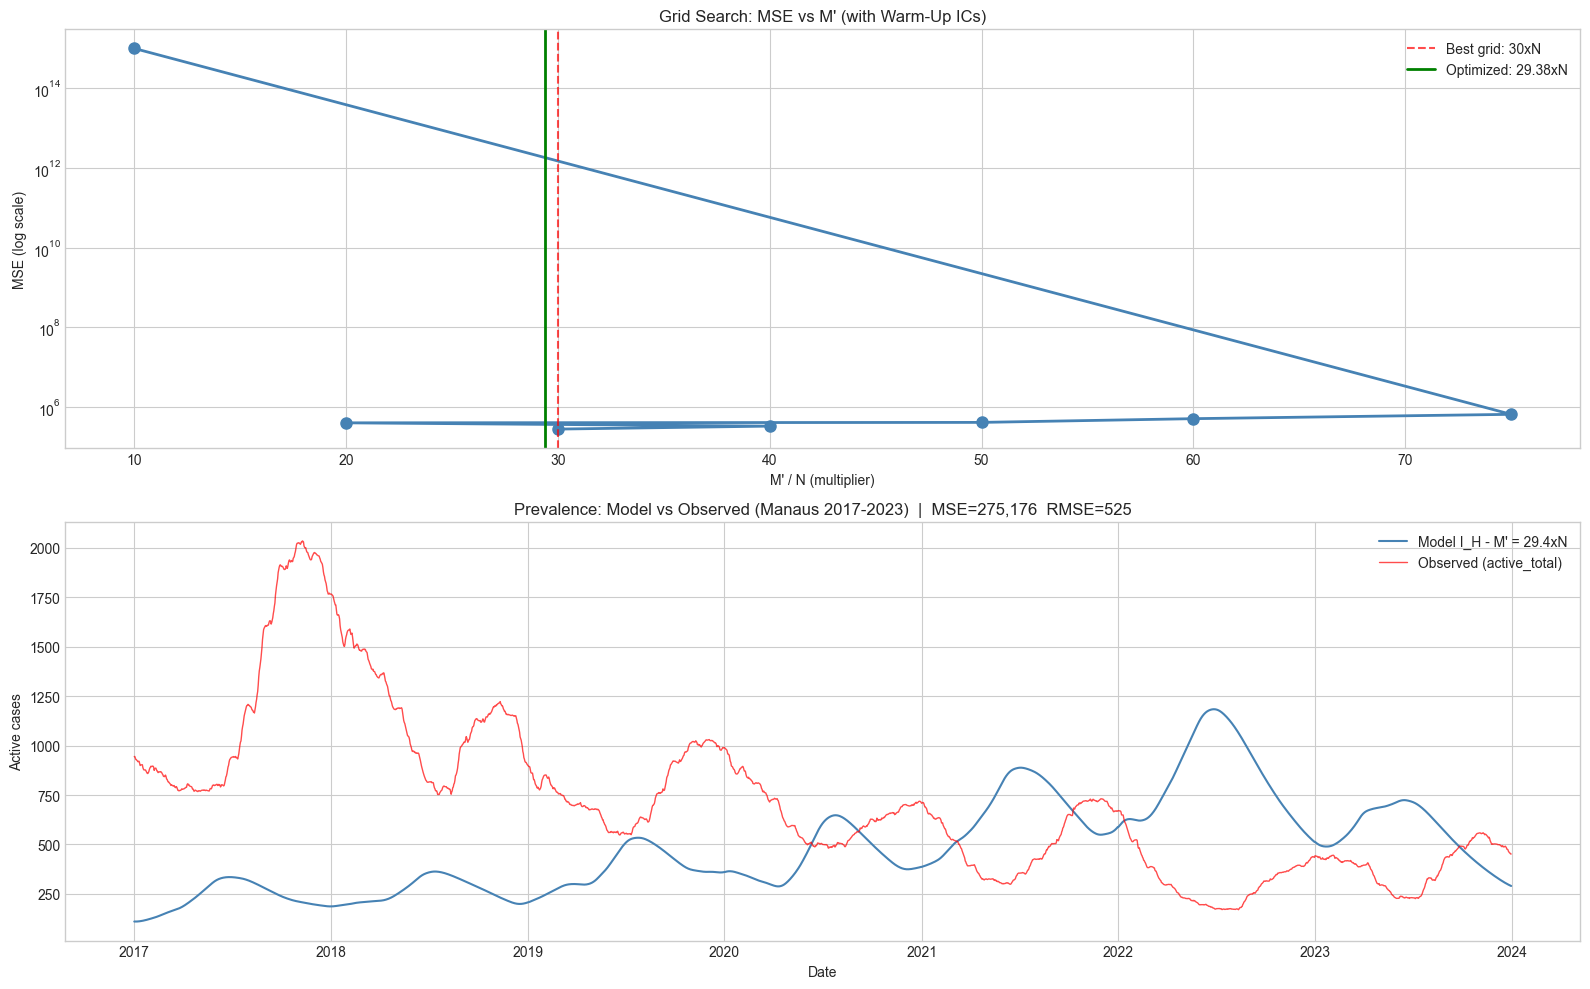


Calibration Summary
  Population N (2017):                8,369
  Warm-up N (2012):                  8,914
  Warm-up M_prime:                 356,560
  Optimal M':                      245,848
  Optimal M' / N (2017):             29.38
  Final MSE:                         275,176.14
  Final RMSE:                            524.57


In [19]:
print("Final simulation with optimal M' (consistent warm-up)...")

#### Re-run warm-up with optimal M' for consistent 2017 ICs
def ode_warmup_final(t, z):
    return seirs_sei_ode(
        t, z, N_warmup, climate_full,
        T_prime, B_E, p_ME, p_ML, p_MP, tau_E, tau_P,
        c1, c2, D1, b1, b2, A, B, C, DD,
        Tmin, optimal_temp_plasm, critical_max_temp_plasm,
        optimal_temp_anop, critical_max_temp_anop, critical_min_temp_anop,
        gamma, R_L, M_prime_optimal, tau_H, omega,
        M_min=M_min, permanent_factor=permanent_factor,
        use_smooth_climate=USE_SMOOTH_CLIMATE,
    )

sol_wu_final = solve_ivp(
    ode_warmup_final,
    (0, warmup_end_idx),
    state_warmup_init,
    t_eval=np.arange(0, warmup_end_idx, 1),
    method='LSODA'
)
warmup_end_opt = np.maximum(sol_wu_final.y[:, -1].copy(), 0) if sol_wu_final.success else warmup_end_state

dates_opt, IH_opt = run_simulation_with_M(M_prime_optimal, initial_state=warmup_end_opt)

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

ax1 = axes[0]
mults = [r[1] for r in grid_results]
mses = [r[2] for r in grid_results]
ax1.semilogy(mults, mses, 'o-', color='steelblue', markersize=8, linewidth=2)
ax1.axvline(best_mult, color='red', linestyle='--', alpha=0.7, label=f'Best grid: {best_mult}xN')
ax1.axvline(optimal_multiplier, color='green', linestyle='-', linewidth=2,
            label=f"Optimized: {optimal_multiplier:.2f}xN")
ax1.set_xlabel("M' / N (multiplier)")
ax1.set_ylabel("MSE (log scale)")
ax1.set_title("Grid Search: MSE vs M' (with Warm-Up ICs)")
ax1.legend()

ax2 = axes[1]
ax2.plot(pd.to_datetime(dates_opt), IH_opt, color='steelblue',
         linewidth=1.5, label=f"Model I_H - M' = {optimal_multiplier:.1f}xN")
ax2.plot(rural_cases_df['date'], rural_cases_df['active_total'], color='red',
         linewidth=1.0, alpha=0.7, label='Observed (active_total)'
         )
ax2.set_xlabel('Date')
ax2.set_ylabel('Active cases')
ax2.set_title('Prevalence: Model vs Observed (Manaus 2017-2023)'
              + f'  |  MSE={result.fun:,.0f}  RMSE={np.sqrt(result.fun):,.0f}')
ax2.legend()

plt.tight_layout()
plt.show()

print(f"\nCalibration Summary")
print(f"  Population N (2017):           {N_2017:>10,}")
print(f"  Warm-up N (2012):             {N_warmup:>10,}")
print(f"  Warm-up M_prime:              {M_prime_warmup:>10,.0f}")
print(f"  Optimal M':                   {M_prime_optimal:>10,.0f}")
print(f"  Optimal M' / N (2017):        {optimal_multiplier:>10.2f}")
print(f"  Final MSE:                    {result.fun:>15,.2f}")
print(f"  Final RMSE:                   {np.sqrt(result.fun):>15,.2f}")


## Final Simulation: All Compartments (2017–2023)

Year-by-year simulation with optimal M' (using calibrated warm-up ICs) and plots of all model compartments.


In [21]:
#### Final simulation with optimal M' (year by year output, consistent warm-up)
M_prime_optimal_val = M_prime_optimal
years = list(range(2017, 2024))
all_results = []
#### Use consistent warm-up end state (re-run with optimal M' above)
current_state = warmup_end_opt.copy() if 'warmup_end_opt' in dir() else warmup_end_state.copy()

for year in years:
    print(f"\nSimulating {year}...")
    N = round(pop_by_year[year])
    start = f"{year}-01-01"
    end = f"{year}-12-31"
    year_climate = climate_data[
        (climate_data['date'] >= start) & (climate_data['date'] <= end)
    ].reset_index(drop=True)
    if USE_SMOOTH_CLIMATE:
        year_climate['temp_med_smooth'] = year_climate['temp_med'].rolling(SMOOTH_WINDOW, min_periods=1, center=False).mean()
        year_climate['precip_med_smooth'] = year_climate['precip_med'].rolling(SMOOTH_WINDOW, min_periods=1, center=False).mean()
        year_climate['umid_min_smooth'] = year_climate['umid_min'].rolling(SMOOTH_WINDOW, min_periods=1, center=False).mean()
    num_days = len(year_climate)
    print(f"Year {year}: N={N}, Days={num_days}")

    def ode_func(t, z):
        return seirs_sei_ode(t, z, N, year_climate,
                            T_prime, B_E, p_ME, p_ML, p_MP, tau_E, tau_P,
                            c1, c2, D1, b1, b2, A, B, C, DD,
                            Tmin, optimal_temp_plasm, critical_max_temp_plasm,
                            optimal_temp_anop, critical_max_temp_anop, critical_min_temp_anop,
                            gamma, R_L, M_prime_optimal_val, tau_H, omega,
                            M_min=M_min, permanent_factor=permanent_factor,
                            use_smooth_climate=USE_SMOOTH_CLIMATE)

    sol = solve_ivp(ode_func, [0, num_days], current_state,
                    t_eval=np.linspace(0, num_days, num_days*10), method='LSODA')

    all_results.append({'year': year, 'N': N, 'sol': sol, 'climate': year_climate})
    current_state = sol.y[:, -1].copy()
    print(f"Finished {year}. Final I_H: {round(current_state[2])}, Final I_M: {round(current_state[6])}")

print("\nAll years simulated successfully!")



Simulating 2017...
Year 2017: N=8369, Days=365
Finished 2017. Final I_H: 187, Final I_M: 216

Simulating 2018...
Year 2018: N=8260, Days=365
Finished 2018. Final I_H: 206, Final I_M: 309

Simulating 2019...
Year 2019: N=8153, Days=365
Finished 2019. Final I_H: 360, Final I_M: 509

Simulating 2020...
Year 2020: N=8045, Days=366
Finished 2020. Final I_H: 387, Final I_M: 424

Simulating 2021...
Year 2021: N=7939, Days=365
Finished 2021. Final I_H: 588, Final I_M: 947

Simulating 2022...
Year 2022: N=7832, Days=365
Finished 2022. Final I_H: 513, Final I_M: 193

Simulating 2023...
Year 2023: N=7942, Days=365
Finished 2023. Final I_H: 290, Final I_M: 100

All years simulated successfully!


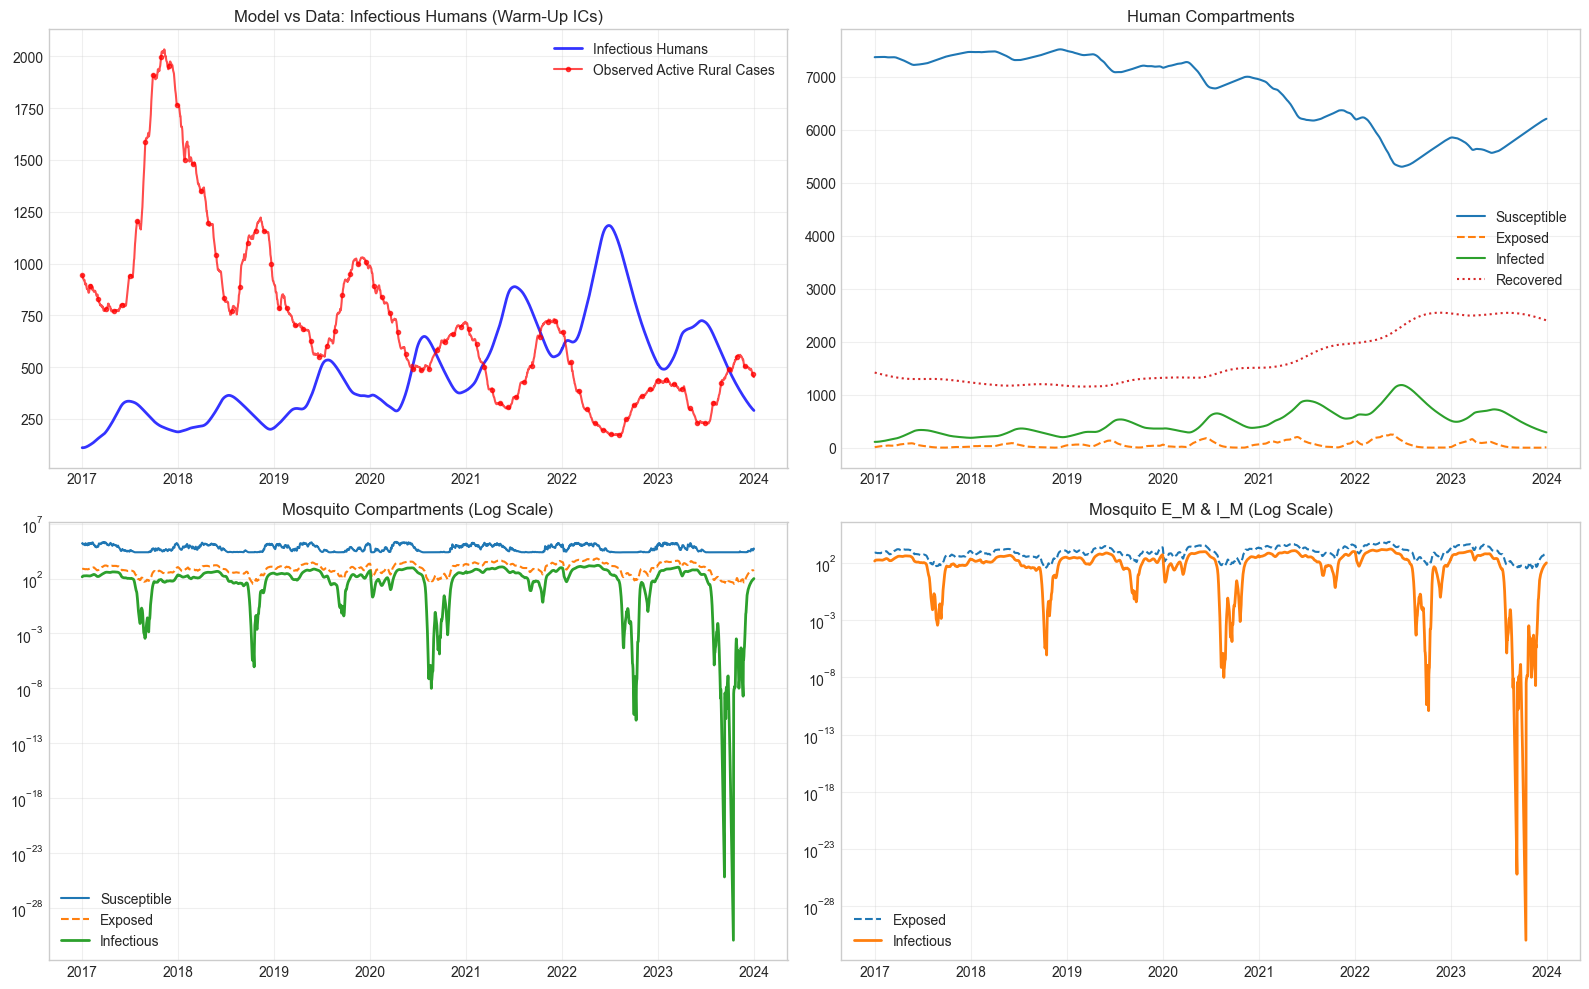

In [22]:
#### Combine and plot all compartments
combined_df = pd.DataFrame()
for res in all_results:
    year = res['year']
    sol = res['sol']
    climate = res['climate']
    t_interp = np.linspace(0, sol.t[-1], len(climate))
    interp = [interp1d(sol.t, sol.y[i])(t_interp) for i in range(7)]
    df = pd.DataFrame({
        'date': pd.to_datetime(climate['date']).values,
        'S_H': interp[0], 'E_H': interp[1], 'I_H': interp[2], 'R_H': interp[3],
        'S_M': interp[4], 'E_M': interp[5], 'I_M': interp[6], 'N': res['N']
    })
    combined_df = pd.concat([combined_df, df]).reset_index(drop=True)

combined_df['date'] = pd.to_datetime(combined_df['date'])
rural_cases_df['date'] = pd.to_datetime(rural_cases_df['date'])

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Infectious humans vs observed data
axes[0,0].plot(combined_df['date'], combined_df['I_H'], 'b-', linewidth=2, label='Infectious Humans', alpha=0.8)
axes[0,0].plot(rural_cases_df['date'], rural_cases_df['active_total'], 'r-', linewidth=1.5,
        label='Observed Active Rural Cases', alpha=0.7, marker='o',
        markersize=3, markevery=30)
axes[0,0].set_title('Model vs Data: Infectious Humans (Warm-Up ICs)')
axes[0,0].legend(); axes[0,0].grid(True, alpha=0.3)

# Human compartments
axes[0,1].plot(combined_df['date'], combined_df['S_H'], label='Susceptible')
axes[0,1].plot(combined_df['date'], combined_df['E_H'], label='Exposed', linestyle='--')
axes[0,1].plot(combined_df['date'], combined_df['I_H'], label='Infected', linestyle='-')
axes[0,1].plot(combined_df['date'], combined_df['R_H'], label='Recovered', linestyle=':')
axes[0,1].set_title('Human Compartments'); axes[0,1].legend(); axes[0,1].grid(True, alpha=0.3)

# Mosquito compartments (log scale)
axes[1,0].plot(combined_df['date'], combined_df['S_M'], label='Susceptible', linewidth=1.5)
axes[1,0].plot(combined_df['date'], combined_df['E_M'], label='Exposed', linewidth=1.5, linestyle='--')
axes[1,0].plot(combined_df['date'], combined_df['I_M'], label='Infectious', linewidth=2)
axes[1,0].set_yscale('log')
axes[1,0].set_title('Mosquito Compartments (Log Scale)'); axes[1,0].legend(); axes[1,0].grid(True, alpha=0.3, which='both')

# Mosquito E_M and I_M (log scale)
axes[1,1].plot(combined_df['date'], combined_df['E_M'], label='Exposed', linewidth=1.5, linestyle='--')
axes[1,1].plot(combined_df['date'], combined_df['I_M'], label='Infectious', linewidth=2)
axes[1,1].set_yscale('log')
axes[1,1].set_title('Mosquito E_M & I_M (Log Scale)'); axes[1,1].legend(); axes[1,1].grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()
